In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde
from scipy.spatial import procrustes
from sklearn.manifold import TSNE
import os

RANDOM_STATE = 42


In [2]:
Z = np.load("pca_outputs/pca_coordinates.npy")
clusters = np.load("pca_outputs/user_clusters.npy")

print("Shape:", Z.shape)

# Load raw feature matrix saved by 04_PCA.ipynb
X = np.load("pca_outputs/feature_matrix_X.npy")
print("Feature matrix X shape:", X.shape)


Shape: (315284, 6)


In [3]:
TSNE_SAMPLE = 50_000

rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(Z), TSNE_SAMPLE, replace=False)

Z_sample = Z[idx]
clusters_sample = clusters[idx]

In [4]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1000,          
    random_state=RANDOM_STATE,
    method="barnes_hut",
    verbose=1
)

Z_tsne = tsne.fit_transform(Z_sample)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 50000 samples in 0.071s...
[t-SNE] Computed neighbors for 50000 samples in 2.905s...
[t-SNE] Computed conditional probabilities for sample 1000 / 50000
[t-SNE] Computed conditional probabilities for sample 2000 / 50000
[t-SNE] Computed conditional probabilities for sample 3000 / 50000
[t-SNE] Computed conditional probabilities for sample 4000 / 50000
[t-SNE] Computed conditional probabilities for sample 5000 / 50000
[t-SNE] Computed conditional probabilities for sample 6000 / 50000
[t-SNE] Computed conditional probabilities for sample 7000 / 50000
[t-SNE] Computed conditional probabilities for sample 8000 / 50000
[t-SNE] Computed conditional probabilities for sample 9000 / 50000
[t-SNE] Computed conditional probabilities for sample 10000 / 50000
[t-SNE] Computed conditional probabilities for sample 11000 / 50000
[t-SNE] Computed conditional probabilities for sample 12000 / 50000
[t-SNE] Computed conditional probabilities for sam

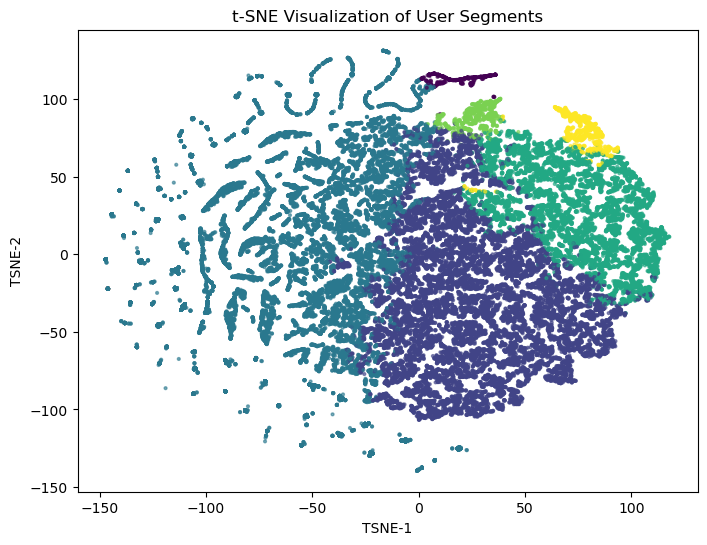

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(
    Z_tsne[:,0],
    Z_tsne[:,1],
    c=clusters_sample,
    s=4,
    alpha=0.6
)
plt.title("t-SNE Visualization of User Segments")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.show()

In [6]:
cluster_names = {
    0: "Low Activity / Narrow Behavior",
    1: "Moderate Activity / Focused Users",
    2: "Active / Diverse Users",
    3: "Power Users / Highly Diverse",
    4: "Heavy but Thematically Focused",
    5: "Casual / Low Diversity"
}

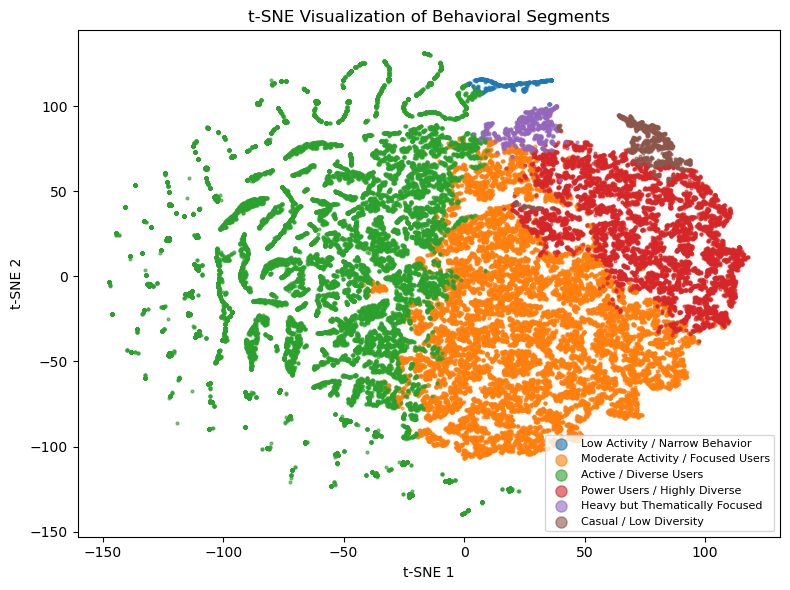

In [7]:
plt.figure(figsize=(8,6))

unique_clusters = sorted(set(clusters_sample))

for cluster_id in unique_clusters:
    mask = clusters_sample == cluster_id
    plt.scatter(
        Z_tsne[mask, 0],
        Z_tsne[mask, 1],
        s=4,
        alpha=0.6,
        label=cluster_names[cluster_id]
    )

plt.title("t-SNE Visualization of Behavioral Segments")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(markerscale=4, fontsize=8)
plt.tight_layout()
plt.show()

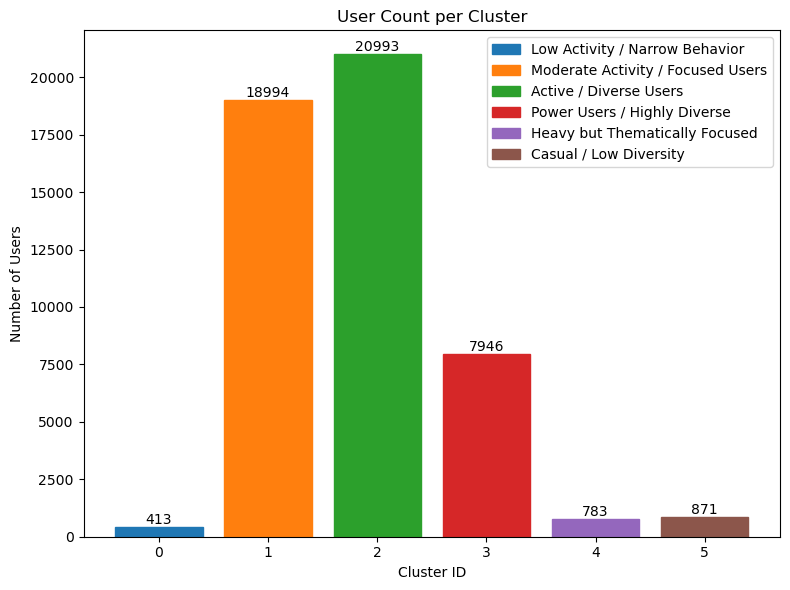

In [8]:
import numpy as np
import matplotlib.pyplot as plt

unique, counts = np.unique(clusters_sample, return_counts=True)

cluster_names = {
    0: "Low Activity / Narrow Behavior",
    1: "Moderate Activity / Focused Users",
    2: "Active / Diverse Users",
    3: "Power Users / Highly Diverse",
    4: "Heavy but Thematically Focused",
    5: "Casual / Low Diversity"
}

colors = plt.cm.tab10(range(len(unique)))

plt.figure(figsize=(8,6))
bars = plt.bar(unique, counts, color=colors)

plt.title("User Count per Cluster")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Users")
plt.xticks(unique)

for bar, cluster_id, count, color in zip(bars, unique, counts, colors):
    bar.set_label(cluster_names.get(cluster_id, f"Cluster {cluster_id}"))
    bar.set_color(color)
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count}",
        ha="center",
        va="bottom"
    )

plt.legend()
plt.tight_layout()
plt.show()

In [9]:
import os

TSNE_OUTPUT_DIR = "tsne_outputs"
os.makedirs(TSNE_OUTPUT_DIR, exist_ok=True)

In [10]:
import numpy as np

np.save(
    os.path.join(TSNE_OUTPUT_DIR, "tsne_coordinates.npy"),
    Z_tsne
)

np.save(
    os.path.join(TSNE_OUTPUT_DIR, "tsne_sample_indices.npy"),
    idx
)

np.save(
    os.path.join(TSNE_OUTPUT_DIR, "tsne_sample_clusters.npy"),
    clusters_sample
)

In [11]:
import pandas as pd

df_tsne = pd.DataFrame({
    "user_index": idx,
    "tsne_1": Z_tsne[:, 0],
    "tsne_2": Z_tsne[:, 1],
    "cluster": clusters_sample
})

df_tsne.to_csv(
    os.path.join(TSNE_OUTPUT_DIR, "tsne_results.csv"),
    index=False
)

In [27]:
# NOTE: feature_matrix_X.npy is saved by 04_PCA.ipynb
# Loading it in cell 1 above via: X = np.load("pca_outputs/feature_matrix_X.npy")


In [28]:
# X is already loaded in the data loading cell above.
# Just recompute X_sample using the already-loaded idx.
if 'X' not in dir() or X is None:
    X = np.load("pca_outputs/feature_matrix_X.npy")
    print("Loaded X from file:", X.shape)

idx = np.load("tsne_outputs/tsne_sample_indices.npy")
X_sample = X[idx]
print("X_sample shape:", X_sample.shape)  # expect (50000, 12)


FileNotFoundError: [Errno 2] No such file or directory: 'pca_outputs/feature_matrix_X.npy'

In [12]:
TSNE_OUTPUT_DIR = "tsne_outputs"
os.makedirs(TSNE_OUTPUT_DIR, exist_ok=True)
 
FEATURE_NAMES = [
    "log_total_events",
    "log_num_sessions",
    "avg_events_per_session",
    "log_distinct_items",
    "avg_price",
    "price_variance",
    "min_price",
    "max_price",
    "num_unique_brands",
    "brand_entropy",
    "num_unique_categories",
    "category_entropy",
]

In [17]:
cluster_labels = {
    0: "Low activity / narrow",
    1: "Moderate / focused",
    2: "Active / diverse",
    3: "Power users",
    4: "Heavy / thematic",
    5: "Casual / low diversity",
}

print("Imports done.")

Imports done.


In [18]:
# ════════════════════════════════════════════════════════
# FIX 1 — Print KL divergence to verify convergence
# Your current code runs t-SNE but never checks if it
# actually converged. Always log this.
# ════════════════════════════════════════════════════════
 
print("=" * 60)
print("t-SNE CONVERGENCE CHECK")
print("=" * 60)
print(f"  KL divergence (final) : {tsne.kl_divergence_:.4f}")
print(f"  n_iter ran            : {tsne.n_iter_}")
if tsne.kl_divergence_ > 3.0:
    print("  WARNING: KL divergence is high — consider more iterations")
    print("           or increase max_iter to 2000.")
else:
    print("  OK: KL divergence is acceptable.")

t-SNE CONVERGENCE CHECK
  KL divergence (final) : 1.6590
  n_iter ran            : 999
  OK: KL divergence is acceptable.


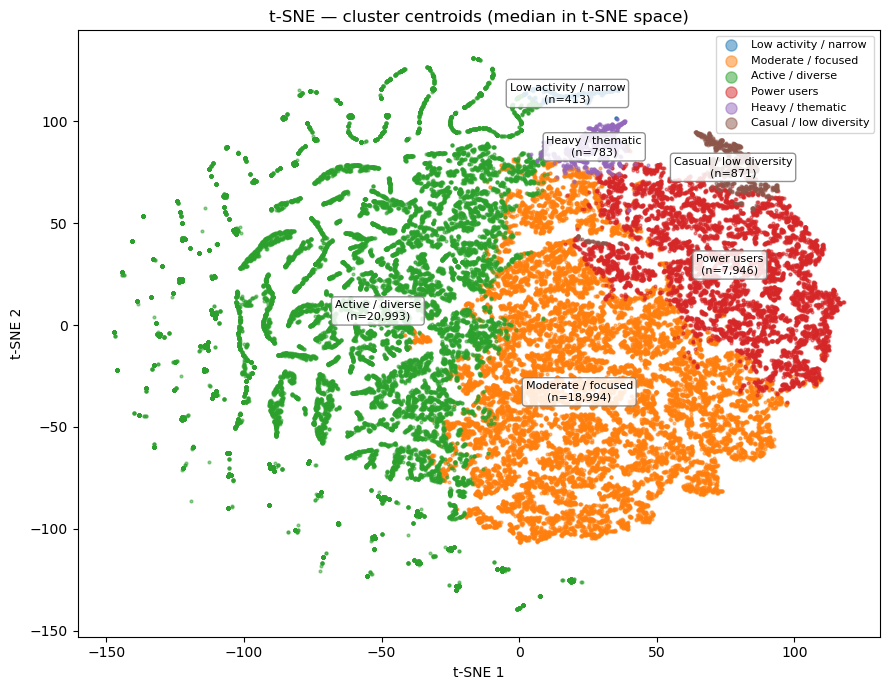

In [19]:
colors = plt.cm.tab10(range(len(np.unique(clusters_sample))))

# Correct: compute median of t-SNE coords per cluster
tsne_centroids = {}
for cid in np.unique(clusters_sample):
    mask = clusters_sample == cid
    tsne_centroids[cid] = np.median(Z_tsne[mask], axis=0)

fig, ax = plt.subplots(figsize=(9, 7))

for i, cid in enumerate(sorted(np.unique(clusters_sample))):
    mask = clusters_sample == cid
    ax.scatter(
        Z_tsne[mask, 0], Z_tsne[mask, 1],
        s=4, alpha=0.5, color=colors[i],
        label=cluster_labels.get(cid, f"Cluster {cid}")
    )
    cx, cy = tsne_centroids[cid]
    count = mask.sum()
    ax.annotate(
        f"{cluster_labels.get(cid, f'C{cid}')}\n(n={count:,})",
        xy=(cx, cy), fontsize=8, ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.85),
    )

ax.set_title("t-SNE — cluster centroids (median in t-SNE space)")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(markerscale=4, fontsize=8, loc="best")
plt.tight_layout()
plt.savefig(os.path.join(TSNE_OUTPUT_DIR, "tsne_annotated_centroids.png"),
            dpi=150, bbox_inches="tight")
plt.show()

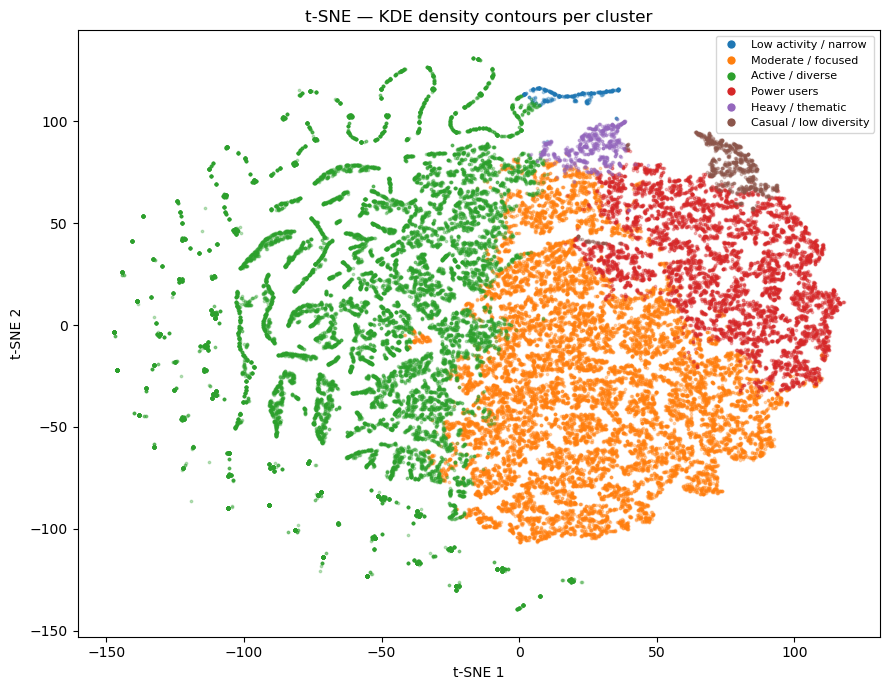

In [20]:
fig, ax = plt.subplots(figsize=(9, 7))

for i, cid in enumerate(sorted(np.unique(clusters_sample))):
    mask = clusters_sample == cid
    pts  = Z_tsne[mask]

    ax.scatter(pts[:, 0], pts[:, 1],
               s=3, alpha=0.3, color=colors[i])

    if mask.sum() > 200:
        try:
            kde  = gaussian_kde(pts.T, bw_method=0.3)
            xmin, xmax = pts[:, 0].min() - 2, pts[:, 0].max() + 2
            ymin, ymax = pts[:, 1].min() - 2, pts[:, 1].max() + 2
            xx, yy = np.mgrid[xmin:xmax:80j, ymin:ymax:80j]
            zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
            ax.contour(xx, yy, zz, levels=3,
                       colors=[colors[i]], alpha=0.7, linewidths=0.9)
        except Exception:
            pass

handles = [
    plt.Line2D([0],[0], marker='o', color='w',
               markerfacecolor=colors[i], markersize=7,
               label=cluster_labels.get(cid, f"Cluster {cid}"))
    for i, cid in enumerate(sorted(np.unique(clusters_sample)))
]
ax.set_title("t-SNE — KDE density contours per cluster")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(handles=handles, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(TSNE_OUTPUT_DIR, "tsne_density_contours.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [26]:
# Get feature values for the sampled users
X_sample = X[idx]  # shape: (N_sample, 12)

features_to_plot = [
    (0,  "log_total_events",       "Activity intensity"),
    (3,  "log_distinct_items",     "Item diversity"),
    (9,  "brand_entropy",          "Brand entropy"),
    (11, "category_entropy",       "Category entropy"),
    (4,  "avg_price",              "Average price"),
    (2,  "avg_events_per_session", "Session intensity"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for ax, (feat_idx, feat_name, feat_label) in zip(axes, features_to_plot):
    vals = X_sample[:, feat_idx]
    vmin = np.percentile(vals, 2)
    vmax = np.percentile(vals, 98)
    sc = ax.scatter(
        Z_tsne[:, 0], Z_tsne[:, 1],
        c=vals, cmap="viridis",
        s=3, alpha=0.5,
        vmin=vmin, vmax=vmax
    )
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(feat_label, fontsize=11)
    ax.set_xlabel("t-SNE 1", fontsize=8)
    ax.set_ylabel("t-SNE 2", fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle("t-SNE colored by individual features", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(TSNE_OUTPUT_DIR, "tsne_feature_coloring.png"),
            dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'X' is not defined

Running perplexity sensitivity — this takes ~5-10 min ...
  perplexity=5  KL=3.1279
  perplexity=30  KL=2.2625
  perplexity=50  KL=2.0369
  perplexity=100  KL=1.7708


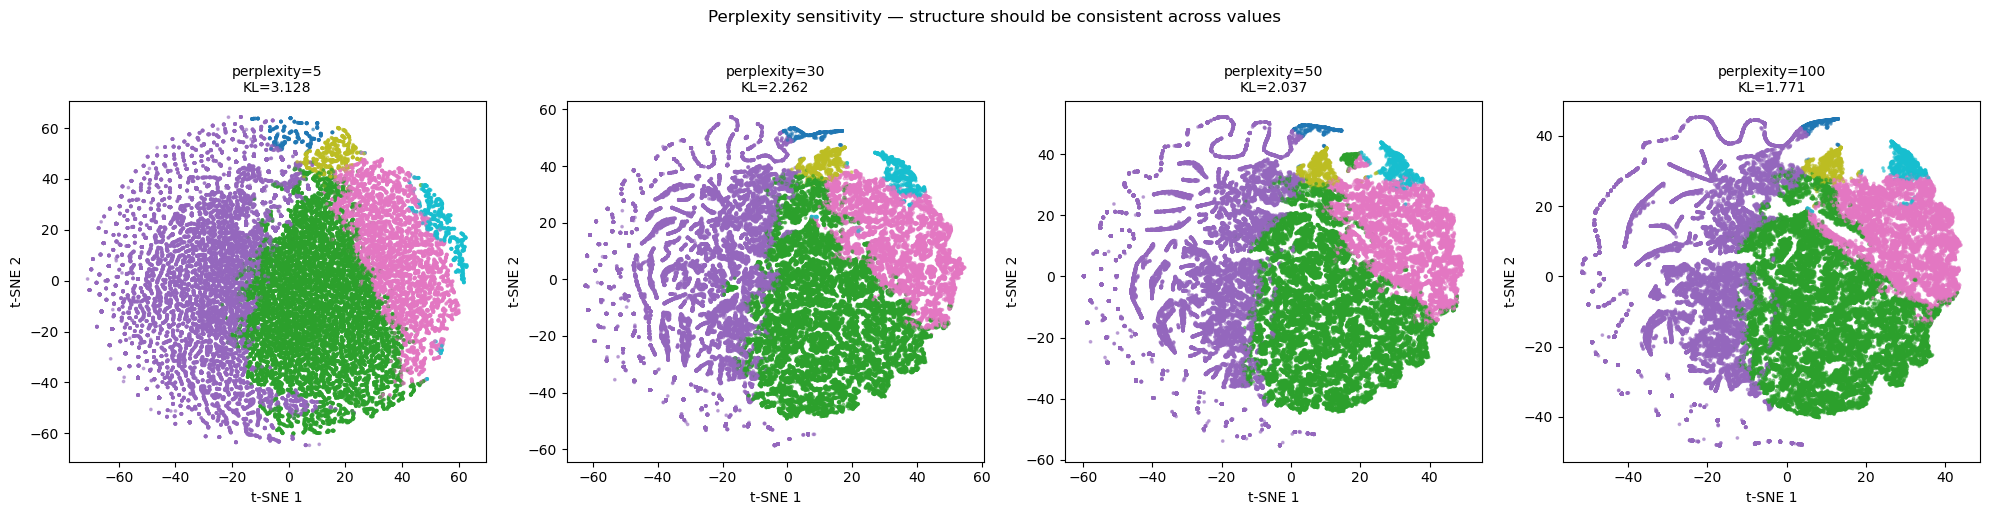

In [22]:
perplexities = [5, 30, 50, 100]
print("Running perplexity sensitivity — this takes ~5-10 min ...")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, perp in zip(axes, perplexities):
    tsne_p = TSNE(
        n_components=2,
        perplexity=perp,
        learning_rate="auto",
        init="pca",
        max_iter=500,
        random_state=123,
        method="barnes_hut",
        verbose=0,
    )
    Z_p = tsne_p.fit_transform(Z_sample)
    ax.scatter(
        Z_p[:, 0], Z_p[:, 1],
        c=clusters_sample, cmap="tab10",
        s=3, alpha=0.5
    )
    ax.set_title(f"perplexity={perp}\nKL={tsne_p.kl_divergence_:.3f}", fontsize=10)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    print(f"  perplexity={perp}  KL={tsne_p.kl_divergence_:.4f}")

plt.suptitle("Perplexity sensitivity — structure should be consistent across values",
             y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(TSNE_OUTPUT_DIR, "tsne_perplexity_sensitivity.png"),
            dpi=150, bbox_inches="tight")
plt.show()

Running t-SNE stability check (seed 123 vs 999) ...
  Procrustes disparity : 0.017403
  Acceptable stability.


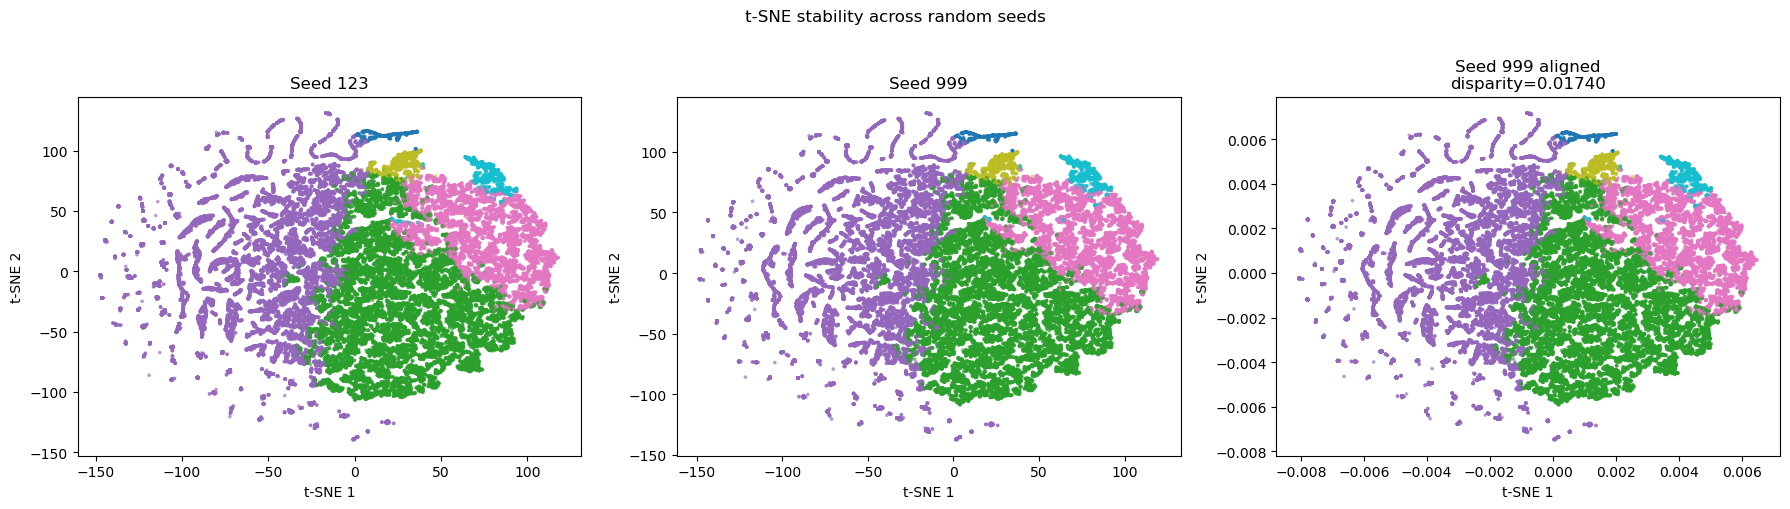

In [29]:
print("Running t-SNE stability check (seed 123 vs 999) ...")

tsne_s1 = TSNE(
    n_components=2, perplexity=30, learning_rate="auto",
    init="pca", max_iter=1000, random_state=RANDOM_STATE,
    method="barnes_hut", verbose=0
)
Z_s1 = tsne_s1.fit_transform(Z_sample)

tsne_s2 = TSNE(
    n_components=2, perplexity=30, learning_rate="auto",
    init="pca", max_iter=1000, random_state=999,
    method="barnes_hut", verbose=0
)
Z_s2 = tsne_s2.fit_transform(Z_sample)

_, Z_s2_aligned, disparity = procrustes(Z_s1, Z_s2)

print(f"  Procrustes disparity : {disparity:.6f}")
if disparity < 0.01:
    print("  Excellent stability.")
elif disparity < 0.05:
    print("  Acceptable stability.")
else:
    print("  NOTE: higher disparity — mention this in the report.")

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

for ax, Z_plot, title in [
    (ax1, Z_s1,         "Seed 123"),
    (ax2, Z_s2,         "Seed 999"),
    (ax3, Z_s2_aligned, f"Seed 999 aligned\ndisparity={disparity:.5f}"),
]:
    ax.scatter(Z_plot[:, 0], Z_plot[:, 1],
               c=clusters_sample, cmap="tab10", s=3, alpha=0.5)
    ax.set_title(title)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.suptitle("t-SNE stability across random seeds", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(TSNE_OUTPUT_DIR, "tsne_stability_seeds.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
tsne_metrics = pd.DataFrame({
    "metric": [
        "kl_divergence_final",
        "n_iter_ran",
        "perplexity_used",
        "sample_size",
        "procrustes_disparity_seed123_vs_999",
    ],
    "value": [
        round(float(tsne.kl_divergence_), 4),
        int(tsne.n_iter_),
        30,
        int(len(Z_sample)),
        round(float(disparity), 6),
    ]
})

tsne_metrics.to_csv(
    os.path.join(TSNE_OUTPUT_DIR, "tsne_metrics.csv"), index=False
)

print(tsne_metrics.to_string(index=False))
print("\nSaved to:", TSNE_OUTPUT_DIR)
print("Files produced:")
for f in [
    "tsne_annotated_centroids.png",
    "tsne_density_contours.png",
    "tsne_feature_coloring.png",
    "tsne_perplexity_sensitivity.png",
    "tsne_stability_seeds.png",
    "tsne_metrics.csv",
]:
    print(f"  {f}")